# Movie Recommendation System

## Exploratory Data Analysis (EDA)

Dataset: MovieLens Latest Small Dataset

This notebook explores movie ratings, genres, user behavior, and movie popularity to prepare for building a recommendation system.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


In [4]:
print("Movies Dataset")
display(movies.head())

print("\nRatings Dataset")
display(ratings.head())

Movies Dataset


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings Dataset


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
print("Movies Missing Values")
print(movies.isnull().sum())

print("\nRatings Missing Values")
print(ratings.isnull().sum())

Movies Missing Values
movieId    0
title      0
genres     0
dtype: int64

Ratings Missing Values
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


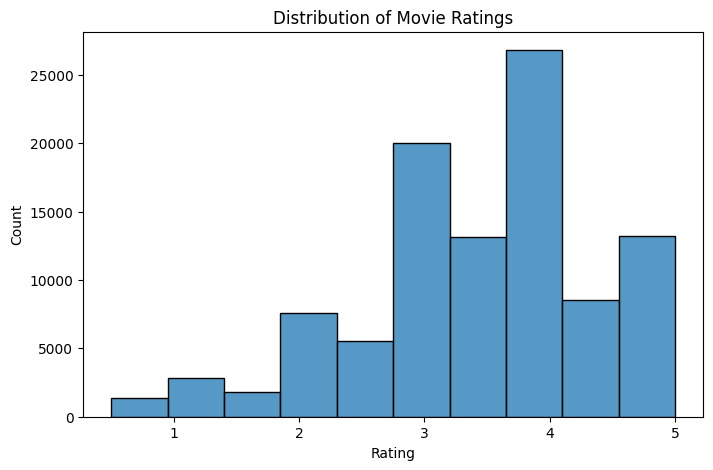

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(ratings["rating"], bins=10)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [7]:
movie_ratings = ratings.groupby("movieId").size()

top_movies = movie_ratings.sort_values(ascending=False).head(10)

top_movies = pd.DataFrame(top_movies).reset_index()
top_movies.columns = ["movieId", "rating_count"]

top_movies = top_movies.merge(movies, on="movieId")

top_movies[["title", "rating_count"]]

,title,rating_count
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278
5,Star Wars: Episode IV - A New Hope (1977),251
6,Jurassic Park (1993),238
7,Braveheart (1995),237
8,Terminator 2: Judgment Day (1991),224
9,Schindler's List (1993),220


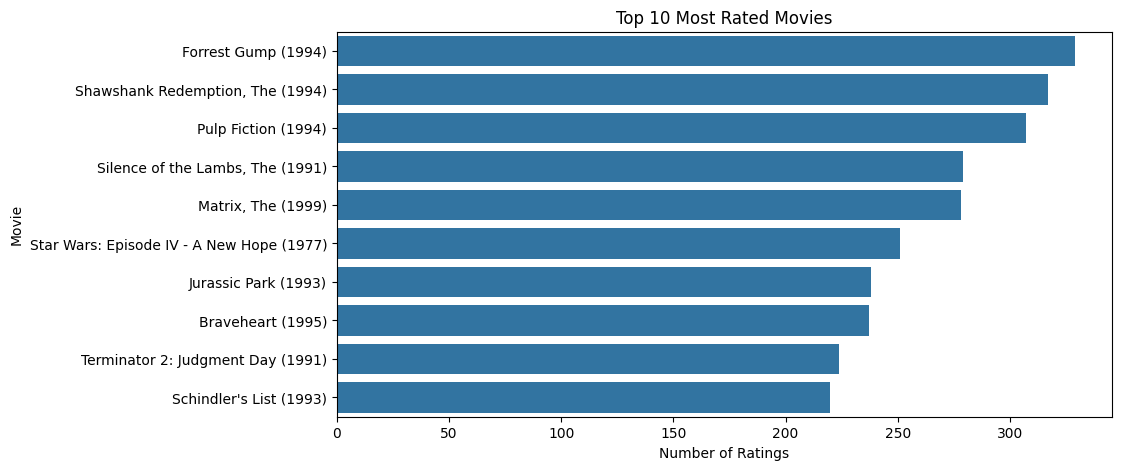

In [8]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_movies,
    x="rating_count",
    y="title"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.show()

In [9]:
movie_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

movie_matrix.head()

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     NaN     4.0     NaN     NaN     4.0     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  9       10      11      12      13      14      15      16      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  17      18      19      20      21      22      23      24      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     3.0     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     4.0     NaN     NaN     NaN   

movieId  25      26      27      28      29      30      31      32      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     0.5     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     2.0   
5           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  34      36      38      39      40      41      42      43      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     4.0     NaN     3.0     NaN     NaN     NaN     NaN   

movieId  44      45      46      47      48      49      50      52      \
userId                                                                    
1           NaN     NaN     NaN     5.0     NaN     NaN     5.0     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     3.0     NaN     2.0     NaN     NaN     NaN     3.0   
5           NaN     NaN     NaN     NaN     NaN     NaN     4.0     NaN   

movieId  53      54      55      57      58      60      61      62      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     3.0     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     5.0     NaN     NaN     NaN   

movieId  63      64      65      66      68      69      70      71      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     3.0     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN   

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(
    movie_matrix.fillna(0).T
)

movie_similarity.shape

(9724, 9724)

In [11]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_matrix.columns,
    columns=movie_matrix.columns
)

movie_similarity_df.head()

movieId    1         2         3         4         5         6         7       \
movieId                                                                         
1        1.000000  0.410562  0.296917  0.035573  0.308762  0.376316  0.277491   
2        0.410562  1.000000  0.282438  0.106415  0.287795  0.297009  0.228576   
3        0.296917  0.282438  1.000000  0.092406  0.417802  0.284257  0.402831   
4        0.035573  0.106415  0.092406  1.000000  0.188376  0.089685  0.275035   
5        0.308762  0.287795  0.417802  0.188376  1.000000  0.298969  0.474002   

movieId    8         9         10        11        12        13        14      \
movieId                                                                         
1        0.131629  0.232586  0.395573  0.323976  0.219680  0.151236  0.178144   
2        0.172498  0.044835  0.417693  0.322252  0.168642  0.194398  0.099373   
3        0.313434  0.304840  0.242954  0.249568  0.203237  0.144049  0.176544   
4        0.158022  0.000000  0.095598  0.153910  0.000000  0.152057  0.110435   
5        0.283523  0.335058  0.218061  0.272182  0.207889  0.116569  0.255333   

movieId    15        16        17        18        19        20        21      \
movieId                                                                         
1        0.104528  0.292152  0.334693  0.167993  0.383641  0.147039  0.335337   
2        0.229191  0.239683  0.208254  0.182717  0.497560  0.129955  0.273282   
3        0.144100  0.294055  0.215245  0.200013  0.279409  0.094867  0.302458   
4        0.157336  0.112660  0.236706  0.000000  0.074807  0.000000  0.129864   
5        0.103934  0.194478  0.276254  0.228271  0.281046  0.051730  0.224821   

movieId    22        23        24        25        26        27        28      \
movieId                                                                         
1        0.226570  0.164626  0.215168  0.324072  0.170520  0.106747  0.124567   
2        0.244361  0.128695  0.203931  0.159834  0.162491  0.151033  0.102551   
3        0.251466  0.151596  0.291192  0.214832  0.198667  0.256104  0.096027   
4        0.160161  0.000000  0.131412  0.179436  0.178241  0.129602  0.053394   
5        0.216080  0.163674  0.235350  0.289412  0.217173  0.279038  0.037623   

movieId    29        30        31        32        34        36        38      \
movieId                                                                         
1        0.190233  0.047388  0.178382  0.508593  0.505196  0.289150  0.135167   
2        0.163939  0.018742  0.244840  0.381811  0.453192  0.180312  0.148042   
3        0.114349  0.000000  0.207695  0.287436  0.220458  0.290828  0.099034   
4        0.040659  0.000000  0.281444  0.086558  0.123893  0.235246  0.000000   
5        0.143247  0.000000  0.252241  0.285743  0.263195  0.301824  0.104168   

movieId    39        40        41        42        43        44        45      \
movieId                                                                         
1        0.351076  0.041815  0.117506  0.101851  0.101023  0.244010  0.185565   
2        0.359441  0.000000  0.121620  0.044393  0.143692  0.319895  0.130049   
3        0.244895  0.099570  0.191409  0.136112  0.200830  0.157972  0.125948   
4        0.058324  0.000000  0.125394  0.000000  0.198794  0.000000  0.165449   
5        0.246391  0.000000  0.178707  0.021816  0.283314  0.078691  0.152664   

movieId    46        47        48        49        50        52        53      \
movieId                                                                         
1        0.151085  0.437659  0.320534  0.068056  0.441003  0.200272  0.048123   
2        0.239552  0.384158  0.418518  0.107667  0.304593  0.089099  0.000000   
3        0.185478  0.279614  0.215533  0.000000  0.204892  0.200625  0.000000   
4        0.354072  0.107234  0.005560  0.000000  0.088874  0.195294  0.000000   
5        0.183241  0.209058  0.244032  0.000000  0.146230  0.259496  0.000000   

movieId    54        55 

In [12]:
def recommend_movies(movie_id, n=5):

    similar_movies = movie_similarity_df[movie_id]

    similar_movies = similar_movies.sort_values(
        ascending=False
    )

    similar_movies = similar_movies.iloc[1:n+1]

    recommended = movies[
        movies["movieId"].isin(similar_movies.index)
    ]

    return recommended[["movieId", "title"]]

In [13]:
recommend_movies(1, 5)

,movieId,title
224,260,Star Wars: Episode IV - A New Hope (1977)
314,356,Forrest Gump (1994)
418,480,Jurassic Park (1993)
615,780,Independence Day (a.k.a. ID4) (1996)
2355,3114,Toy Story 2 (1999)


In [14]:
def recommend_by_title(title, n=5):

    movie = movies[
        movies["title"].str.contains(
            title,
            case=False,
            na=False
        )
    ]

    if len(movie) == 0:
        return "Movie not found"

    movie_id = movie.iloc[0]["movieId"]

    return recommend_movies(movie_id, n)

In [15]:
recommend_by_title("Toy Story")

,movieId,title
224,260,Star Wars: Episode IV - A New Hope (1977)
314,356,Forrest Gump (1994)
418,480,Jurassic Park (1993)
615,780,Independence Day (a.k.a. ID4) (1996)
2355,3114,Toy Story 2 (1999)
